In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded ✓")

Libraries loaded ✓


In [3]:
# FTSE 250 sample constituents
constituents = {
    'IMB.L':  ('Imperial Brands',    'Consumer Staples'),
    'DCC.L':  ('DCC plc',            'Industrials'),
    'IHG.L':  ('IHG Hotels',         'Consumer Discretionary'),
    'EXPN.L': ('Experian',           'Technology'),
    'AUTO.L': ('Auto Trader',        'Technology'),
    'WTB.L':  ('Whitbread',          'Consumer Discretionary'),
    'PSON.L': ('Pearson',            'Communication Services'),
    'SDR.L':  ('Schroders',          'Financials'),
    'HLMA.L': ('Halma',              'Industrials'),
    'RTO.L':  ('Rentokil Initial',   'Industrials'),
}

df_tickers = pd.DataFrame.from_dict(
    constituents, orient='index', columns=['Company', 'Sector']
)
df_tickers.index.name = 'Ticker'
print(f"Tracking {len(df_tickers)} stocks")
df_tickers

Tracking 10 stocks


,Company,Sector
Ticker,,
IMB.L,Imperial Brands,Consumer Staples
DCC.L,DCC plc,Industrials
IHG.L,IHG Hotels,Consumer Discretionary
EXPN.L,Experian,Technology
AUTO.L,Auto Trader,Technology
WTB.L,Whitbread,Consumer Discretionary
PSON.L,Pearson,Communication Services
SDR.L,Schroders,Financials
HLMA.L,Halma,Industrials


In [4]:
tickers = list(constituents.keys())
end_date = datetime.today()
start_date = end_date - timedelta(days=90)

print("Pulling data from Yahoo Finance...")
raw = yf.download(tickers, start=start_date, end=end_date, progress=False)

close = raw['Close'].iloc[-1]
volume_30d = raw['Volume'].tail(30).mean()

print(f"Data pulled for {len(close)} stocks ✓")

Pulling data from Yahoo Finance...
Data pulled for 10 stocks ✓


In [5]:
# Pull shares outstanding for each ticker
shares_data = {}
for ticker in tickers:
    try:
        info = yf.Ticker(ticker).info
        shares = info.get('sharesOutstanding', None)
        shares_data[ticker] = shares
    except:
        shares_data[ticker] = None

# Build the main analysis dataframe
results = []
for ticker in tickers:
    company, sector = constituents[ticker]
    price = close.get(ticker, np.nan)
    shares = shares_data.get(ticker, np.nan)
    adv = volume_30d.get(ticker, np.nan)

    if pd.notna(price) and pd.notna(shares) and pd.notna(adv):
        mktcap_bn = (price * shares) / 1e9

        lower_threshold = 0.5
        upper_threshold = 8.0

        proximity_lower = abs(mktcap_bn - lower_threshold) / lower_threshold
        proximity_upper = abs(mktcap_bn - upper_threshold) / upper_threshold
        rebalance_risk = min(proximity_lower, proximity_upper)

        passive_ownership_pct = 0.25
        shares_to_trade = shares * passive_ownership_pct
        adv_days_needed = shares_to_trade / adv if adv > 0 else np.nan

        results.append({
            'Ticker': ticker,
            'Company': company,
            'Sector': sector,
            'Price (£)': round(price, 2),
            'Mkt Cap (£bn)': round(mktcap_bn, 2),
            'ADV (30d)': int(adv),
            'ADV Days to Trade': round(adv_days_needed, 1),
            'Rebalance Risk Score': round(1 - rebalance_risk, 3),
            'Flag': 'PROMOTION RISK' if mktcap_bn > upper_threshold * 0.85
                    else 'DELETION RISK' if mktcap_bn < lower_threshold * 1.5
                    else 'STABLE'
        })

df_results = pd.DataFrame(results).set_index('Ticker')
df_results = df_results.sort_values('Mkt Cap (£bn)', ascending=False)
print("Model complete ✓")
df_results

Model complete ✓


,Company,Sector,Price (£),Mkt Cap (£bn),ADV (30d),ADV Days to Trade,Rebalance Risk Score,Flag
Ticker,,,,,,,,
IMB.L,Imperial Brands,Consumer Staples,3075.00,2395.97,2828804,68.9,-297.496,PROMOTION RISK
EXPN.L,Experian,Technology,2503.00,2253.29,4443700,50.6,-279.661,PROMOTION RISK
HLMA.L,Halma,Industrials,3720.00,1405.05,1501888,62.9,-173.631,PROMOTION RISK
RTO.L,Rentokil Initial,Industrials,457.60,1151.43,9430675,66.7,-141.929,PROMOTION RISK
SDR.L,Schroders,Financials,572.50,892.71,9286395,42.0,-109.589,PROMOTION RISK
PSON.L,Pearson,Communication Services,953.80,589.53,2942358,52.5,-71.692,PROMOTION RISK
DCC.L,DCC plc,Industrials,4582.00,391.41,705460,30.3,-46.926,PROMOTION RISK
WTB.L,Whitbread,Consumer Discretionary,2260.00,377.29,789517,52.9,-45.161,PROMOTION RISK
AUTO.L,Auto Trader,Technology,447.30,368.16,5834333,35.3,-44.020,PROMOTION RISK


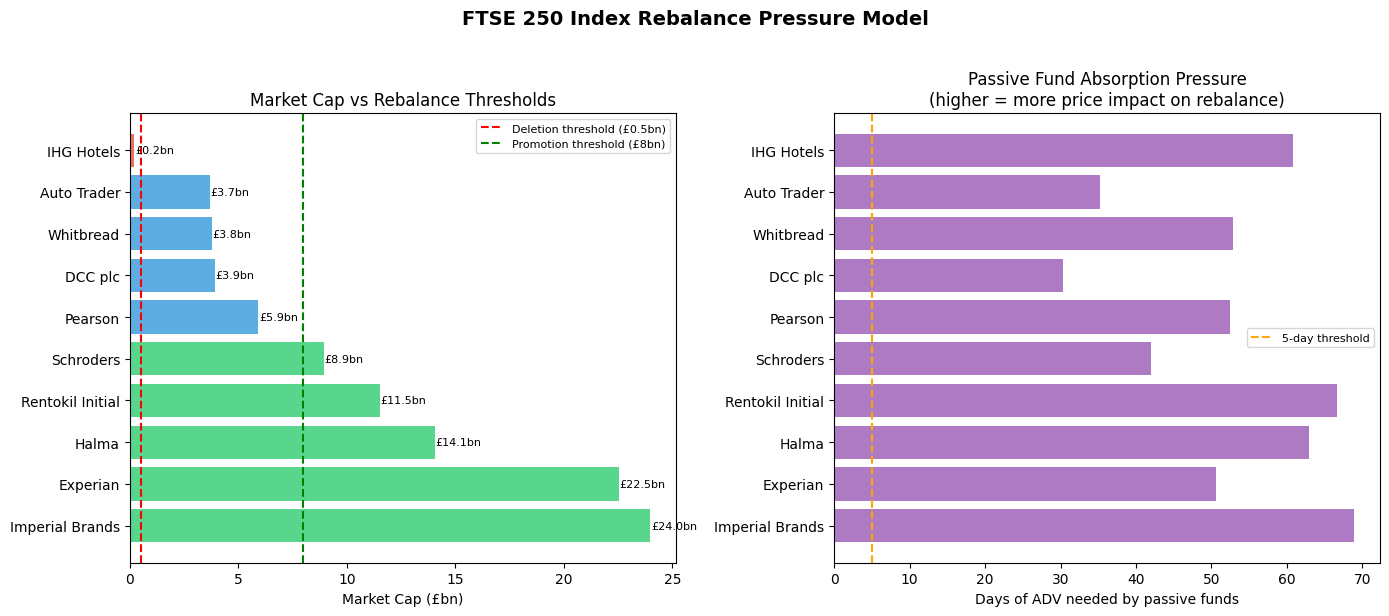

Chart saved ✓


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('FTSE 250 Index Rebalance Pressure Model', fontsize=14, fontweight='bold', y=1.02)

ax1 = axes[0]
colors = {'PROMOTION RISK': '#2ecc71', 'STABLE': '#3498db', 'DELETION RISK': '#e74c3c'}
bar_colors = [colors[f] for f in df_results['Flag']]

bars = ax1.barh(df_results['Company'], df_results['Mkt Cap (£bn)'], color=bar_colors, alpha=0.8)
ax1.axvline(x=0.5, color='red', linestyle='--', linewidth=1.5, label='Deletion threshold (£0.5bn)')
ax1.axvline(x=8.0, color='green', linestyle='--', linewidth=1.5, label='Promotion threshold (£8bn)')
ax1.set_xlabel('Market Cap (£bn)')
ax1.set_title('Market Cap vs Rebalance Thresholds')
ax1.legend(fontsize=8)

for bar, val in zip(bars, df_results['Mkt Cap (£bn)']):
    ax1.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             f'£{val:.1f}bn', va='center', fontsize=8)

ax2 = axes[1]
adv_data = df_results.dropna(subset=['ADV Days to Trade'])
ax2.barh(adv_data['Company'], adv_data['ADV Days to Trade'], color='#9b59b6', alpha=0.8)
ax2.set_xlabel('Days of ADV needed by passive funds')
ax2.set_title('Passive Fund Absorption Pressure\n(higher = more price impact on rebalance)')
ax2.axvline(x=5, color='orange', linestyle='--', linewidth=1.5, label='5-day threshold')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('rebalance_pressure_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved ✓")

In [7]:
# Fix: LSE stocks are priced in pence, divide by 100
results = []
for ticker in tickers:
    company, sector = constituents[ticker]
    price = close.get(ticker, np.nan) / 100  # convert pence to pounds
    shares = shares_data.get(ticker, np.nan)
    adv = volume_30d.get(ticker, np.nan)

    if pd.notna(price) and pd.notna(shares) and pd.notna(adv):
        mktcap_bn = (price * shares) / 1e9

        lower_threshold = 0.5
        upper_threshold = 8.0

        proximity_lower = abs(mktcap_bn - lower_threshold) / lower_threshold
        proximity_upper = abs(mktcap_bn - upper_threshold) / upper_threshold
        rebalance_risk = min(proximity_lower, proximity_upper)

        passive_ownership_pct = 0.25
        shares_to_trade = shares * passive_ownership_pct
        adv_days_needed = shares_to_trade / adv if adv > 0 else np.nan

        results.append({
            'Ticker': ticker,
            'Company': company,
            'Sector': sector,
            'Price (£)': round(price, 2),
            'Mkt Cap (£bn)': round(mktcap_bn, 2),
            'ADV (30d)': int(adv),
            'ADV Days to Trade': round(adv_days_needed, 1),
            'Rebalance Risk Score': round(1 - rebalance_risk, 3),
            'Flag': 'PROMOTION RISK' if mktcap_bn > upper_threshold * 0.85
                    else 'DELETION RISK' if mktcap_bn < lower_threshold * 1.5
                    else 'STABLE'
        })

df_results = pd.DataFrame(results).set_index('Ticker')
df_results = df_results.sort_values('Mkt Cap (£bn)', ascending=False)
print("Model complete ✓")
df_results

Model complete ✓


,Company,Sector,Price (£),Mkt Cap (£bn),ADV (30d),ADV Days to Trade,Rebalance Risk Score,Flag
Ticker,,,,,,,,
IMB.L,Imperial Brands,Consumer Staples,30.75,23.96,2828804,68.9,-0.995,PROMOTION RISK
EXPN.L,Experian,Technology,25.03,22.53,4443700,50.6,-0.817,PROMOTION RISK
HLMA.L,Halma,Industrials,37.20,14.05,1501888,62.9,0.244,PROMOTION RISK
RTO.L,Rentokil Initial,Industrials,4.58,11.51,9430675,66.7,0.561,PROMOTION RISK
SDR.L,Schroders,Financials,5.72,8.93,9286395,42.0,0.884,PROMOTION RISK
PSON.L,Pearson,Communication Services,9.54,5.90,2942358,52.5,0.737,STABLE
DCC.L,DCC plc,Industrials,45.82,3.91,705460,30.3,0.489,STABLE
WTB.L,Whitbread,Consumer Discretionary,22.60,3.77,789517,52.9,0.472,STABLE
AUTO.L,Auto Trader,Technology,4.47,3.68,5834333,35.3,0.460,STABLE


In [9]:
print("=" * 60)
print("ACTIONABLE SIGNALS — FTSE 250 REBALANCE WATCH")
print("=" * 60)

at_risk = df_results[df_results['Flag'] != 'STABLE']
if len(at_risk) > 0:
    for ticker, row in at_risk.iterrows():
        print(f"\n⚡ {row['Company']} ({ticker})")
        print(f"   Flag: {row['Flag']}")
        print(f"   Market Cap: £{row['Mkt Cap (£bn)']:.2f}bn")
        print(f"   Passive funds would need {row['ADV Days to Trade']:.1f} days of ADV to rebalance")
        if row['ADV Days to Trade'] > 5:
            print(f"   → HIGH IMPACT: Expect significant price pressure around rebalance date")
        else:
            print(f"   → Moderate impact expected")
else:
    print("\nNo stocks near rebalance thresholds in current sample.")

print("\n" + "=" * 60)
print(f"Analysis run: {datetime.today().strftime('%d %B %Y')}")

ACTIONABLE SIGNALS — FTSE 250 REBALANCE WATCH

⚡ Imperial Brands (IMB.L)
   Flag: PROMOTION RISK
   Market Cap: £23.96bn
   Passive funds would need 68.9 days of ADV to rebalance
   → HIGH IMPACT: Expect significant price pressure around rebalance date

⚡ Experian (EXPN.L)
   Flag: PROMOTION RISK
   Market Cap: £22.53bn
   Passive funds would need 50.6 days of ADV to rebalance
   → HIGH IMPACT: Expect significant price pressure around rebalance date

⚡ Halma (HLMA.L)
   Flag: PROMOTION RISK
   Market Cap: £14.05bn
   Passive funds would need 62.9 days of ADV to rebalance
   → HIGH IMPACT: Expect significant price pressure around rebalance date

⚡ Rentokil Initial (RTO.L)
   Flag: PROMOTION RISK
   Market Cap: £11.51bn
   Passive funds would need 66.7 days of ADV to rebalance
   → HIGH IMPACT: Expect significant price pressure around rebalance date

⚡ Schroders (SDR.L)
   Flag: PROMOTION RISK
   Market Cap: £8.93bn
   Passive funds would need 42.0 days of ADV to rebalance
   → HIGH IMPA